In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data reading

In [21]:
#Data reading
df = pd.read_csv("taxi_trip_pricing.csv")

#Data understanding
print(df.shape)
print(df.dtypes)

df.head()

(1000, 11)
Trip_Distance_km         float64
Time_of_Day                  str
Day_of_Week                  str
Passenger_Count          float64
Traffic_Conditions           str
Weather                      str
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


## Data quality check

### duplicate

In [ ]:
#duplicate observations
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df) * 100, 2), "%")

Number of duplicated rows: 0
Duplicate percentage: 0.0 %


### categorical values check


In [ ]:
#categorical values check
categorical_columns = df.select_dtypes(include=["str"]).columns
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))




--- Time_of_Day ---
Time_of_Day
Afternoon    371
Morning      283
Evening      203
Night         93
NaN           50
Name: count, dtype: int64

--- Day_of_Week ---
Day_of_Week
Weekday    655
Weekend    295
NaN         50
Name: count, dtype: int64

--- Traffic_Conditions ---
Traffic_Conditions
Low       397
Medium    371
High      182
NaN        50
Name: count, dtype: int64

--- Weather ---
Weather
Clear    667
Rain     227
Snow      56
NaN       50
Name: count, dtype: int64


## Descriptive statistics

In [79]:
#Descriptive statistics
desc = df.describe().T

#add skewness
desc["Skewness"] = df.select_dtypes(include="number").skew()
#add outlier
outlier_counts = {}
for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outlier_counts[col] = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()
desc["Outlier"] = pd.Series(outlier_counts)
#add mode
desc["Mode"] = df.mode().iloc[0]

new_column_order = [
    "count",
    "mean",
    "Mode",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max",
    "Skewness",
    "Outlier",
]

display(desc.reindex(columns=new_column_order))

,count,mean,Mode,std,min,25%,50%,75%,max,Skewness,Outlier
Trip_Distance_km,950.0,27.070547,3.0,19.905300,1.2300,12.63250,25.8300,38.40500,146.067047,2.236010,20
Passenger_Count,950.0,2.476842,3.0,1.102249,1.0000,1.25000,2.0000,3.00000,4.000000,0.016255,0
Base_Fare,950.0,3.502989,3.94,0.870162,2.0100,2.73000,3.5200,4.26000,5.000000,-0.005149,0
Per_Km_Rate,950.0,1.233316,0.63,0.429816,0.5000,0.86000,1.2200,1.61000,2.000000,0.079206,0
Per_Minute_Rate,950.0,0.292916,0.15,0.115592,0.1000,0.19000,0.2900,0.39000,0.500000,0.058695,0
Trip_Duration_Minutes,950.0,62.118116,89.21,32.154406,5.0100,35.88250,61.8600,89.05500,119.840000,0.017749,0
Trip_Price,951.0,56.874773,6.1269,40.469791,6.1269,33.74265,50.0745,69.09935,332.043689,3.732561,26


#### descriptive statistics graphs and plots

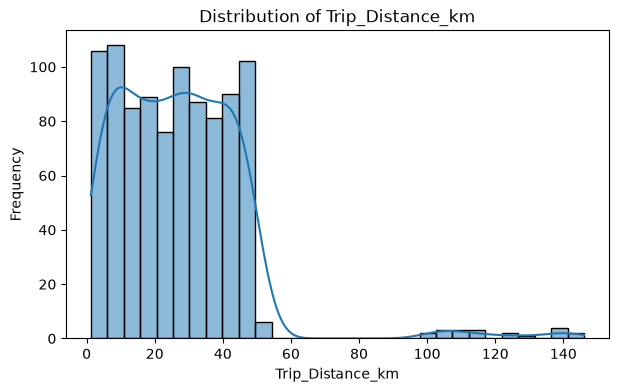

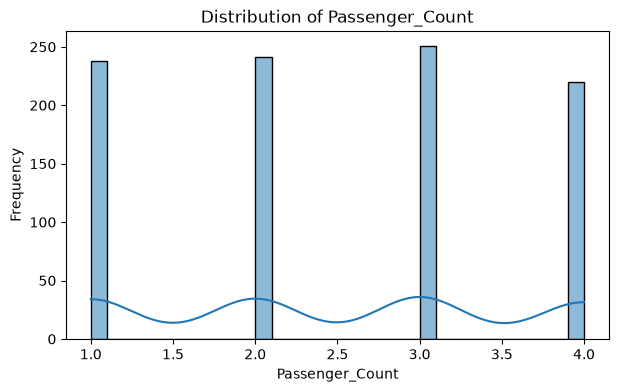

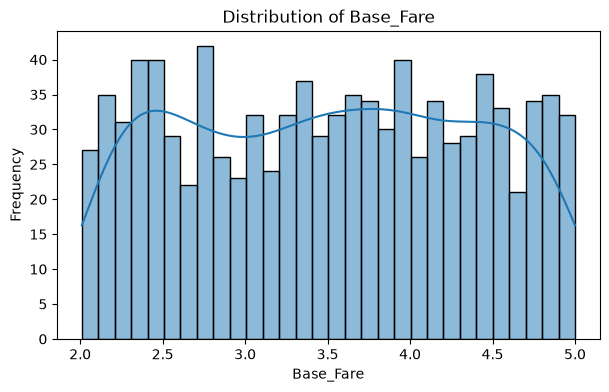

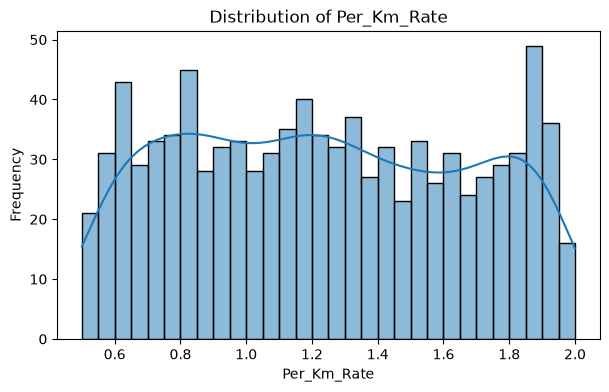

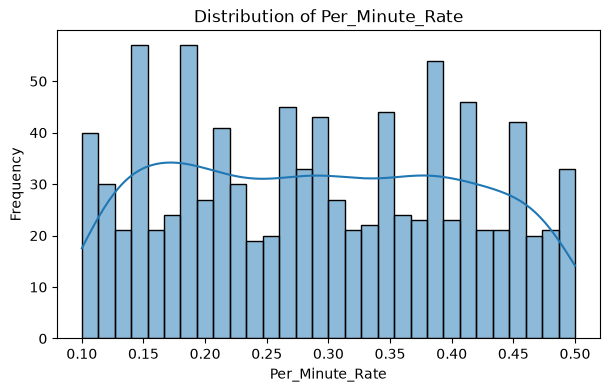

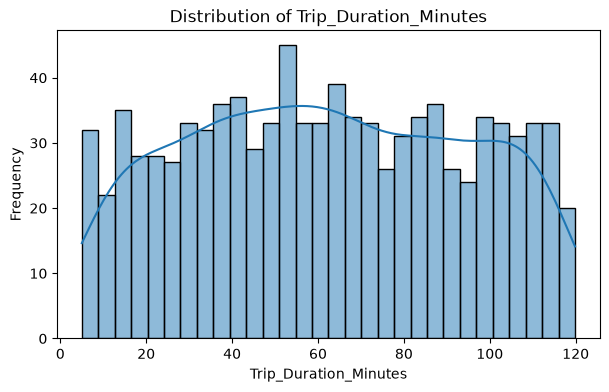

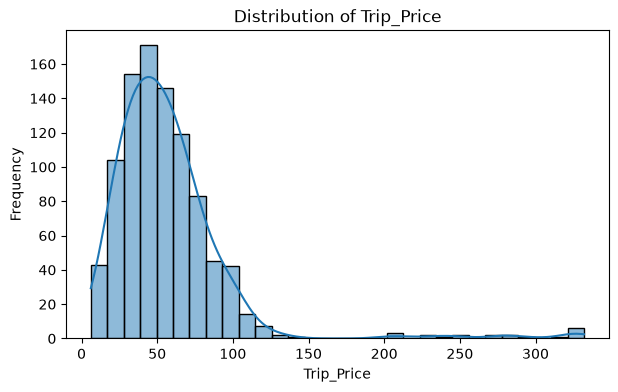

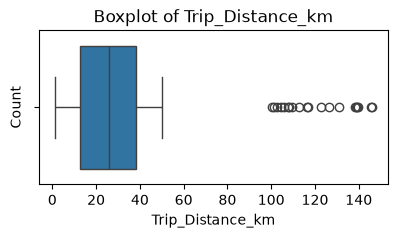

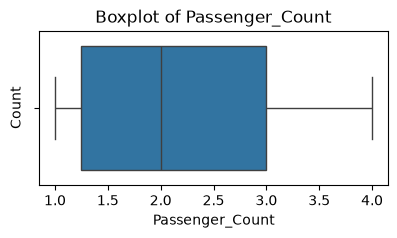

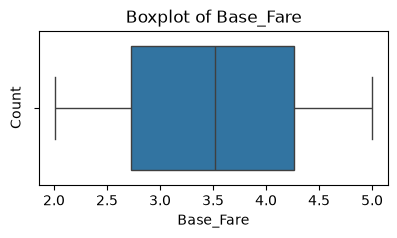

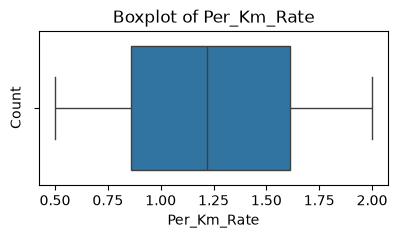

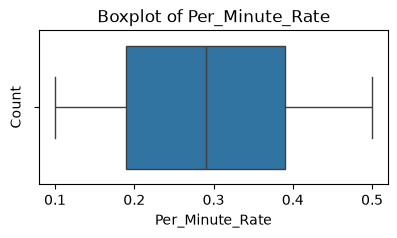

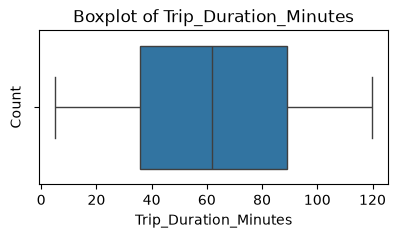

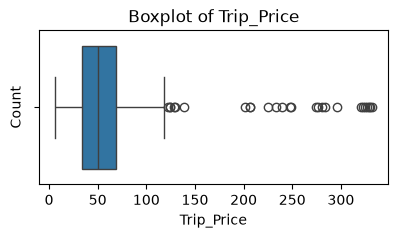

In [91]:
#descriptive statistics
#before data cleaning
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


for col in numeric_cols:
    plt.figure(figsize=(4.5, 2))
    
    sns.boxplot(
        data=df,
        x=col
    )
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

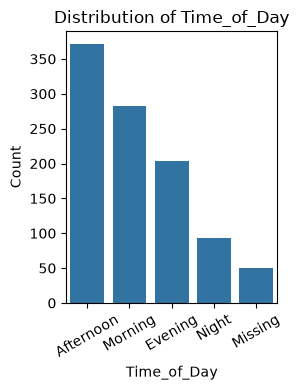

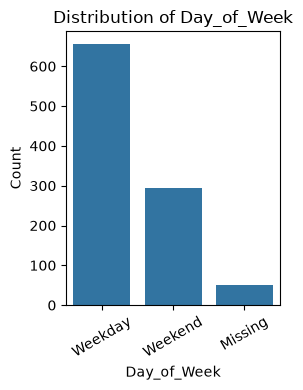

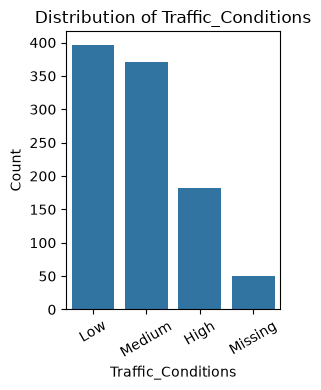

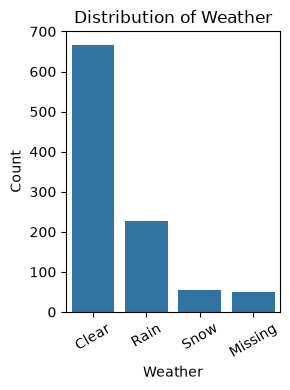

In [81]:
categorical_cols = [
    "Time_of_Day",
    "Day_of_Week",
    "Traffic_Conditions",
    "Weather"
]

for col in categorical_cols:
    plot_data = df[col].fillna("Missing")

    plt.figure(figsize=(3, 4))

    sns.countplot(
        x=plot_data,
        order=plot_data.value_counts().index
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### outliers

In [ ]:
#find outliers
price_upper_fence = df["Trip_Price"].quantile(0.75) + 1.5 * (df["Trip_Price"].quantile(0.75) - df["Trip_Price"].quantile(0.25))
distance_upper_fence = df["Trip_Distance_km"].quantile(0.75) + 1.5 * (df["Trip_Distance_km"].quantile(0.75) - df["Trip_Distance_km"].quantile(0.25))

distance_outliers = df.loc[
    df["Trip_Distance_km"] > distance_upper_fence,
    [
        "Trip_Distance_km",
        "Trip_Duration_Minutes",
        "Base_Fare",
        "Per_Km_Rate",
        "Per_Minute_Rate",
        "Trip_Price"
    ]
].sort_values("Trip_Distance_km")

price_outliers = df.loc[
    df["Trip_Price"] > price_upper_fence,
    [
        "Trip_Distance_km",
        "Trip_Duration_Minutes",
        "Base_Fare",
        "Per_Km_Rate",
        "Per_Minute_Rate",
        "Trip_Price"
    ]
].sort_values("Trip_Price")

display(distance_outliers)
display(price_outliers)

,Trip_Distance_km,Trip_Duration_Minutes,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Price
287,100.380420,89.21,4.46,NaN,NaN,329.913004
747,101.039704,56.78,4.39,1.79,NaN,283.645201
110,102.747556,53.09,2.23,1.80,0.23,274.535087
410,104.371791,89.21,3.22,1.12,0.45,206.508652
22,105.943550,23.03,3.94,1.69,0.32,201.869509
481,107.786832,79.60,2.05,1.30,0.18,322.725996
797,108.146994,97.16,2.25,NaN,0.36,239.171407
141,109.616082,53.88,4.46,1.69,0.23,327.217665
108,112.830958,78.63,3.35,1.90,0.23,233.008285
267,116.196064,19.63,2.20,0.85,0.25,206.699570


,Trip_Distance_km,Trip_Duration_Minutes,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Price
725,NaN,111.65,3.88,1.96,0.32,122.418000
411,47.550000,94.35,4.78,1.97,0.27,123.928000
522,48.530000,60.77,4.57,1.94,NaN,124.241600
751,47.050000,77.86,2.52,1.87,0.49,128.654900
671,44.940000,103.37,NaN,1.83,0.42,129.535600
795,43.730000,108.76,4.64,1.97,0.44,138.642500
22,105.943550,23.03,3.94,1.69,0.32,201.869509
410,104.371791,89.21,3.22,1.12,0.45,206.508652
267,116.196064,19.63,2.20,0.85,0.25,206.699570
835,126.547628,29.30,4.23,0.85,0.28,224.914663


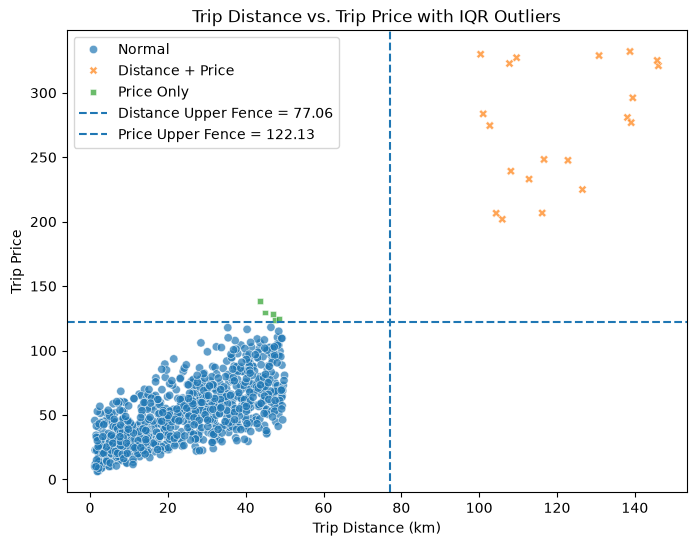

In [ ]:
# Classify observations by outlier type
plot_df = df.copy()

plot_df["Outlier_Type"] = "Normal"

plot_df.loc[
    plot_df["Trip_Price"] > price_upper_fence,
    "Outlier_Type"
] = "Price Only"

plot_df.loc[
    (plot_df["Trip_Distance_km"] > distance_upper_fence) &
    (plot_df["Trip_Price"] > price_upper_fence),
    "Outlier_Type"
] = "Distance + Price"


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="Trip_Distance_km",
    y="Trip_Price",
    hue="Outlier_Type",
    style="Outlier_Type",
    alpha=0.7
)

plt.axvline(
    distance_upper_fence,
    linestyle="--",
    label=f"Distance Upper Fence = {distance_upper_fence:.2f}"
)

plt.axhline(
    price_upper_fence,
    linestyle="--",
    label=f"Price Upper Fence = {price_upper_fence:.2f}"
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Price")
plt.title("Trip Distance vs. Trip Price with IQR Outliers")

plt.legend()
plt.show()

### Missing value

In [66]:
#missing value
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": df.isnull().mean() * 100
})

display(missing_summary)

missing_per_row = df.isnull().sum(axis=1)
missing_per_row.value_counts().sort_index()

missing_per_row_summary = pd.DataFrame({
    "Missing Variables": missing_per_row.value_counts().sort_index().index,
    "Number of Rows": missing_per_row.value_counts().sort_index().values
})
missing_per_row_summary["Percentage (%)"] = (
    missing_per_row_summary["Number of Rows"] / len(df) * 100
).round(2)

display(missing_per_row_summary)


,Missing Count,Missing Percentage (%)
Trip_Distance_km,50,5.0
Time_of_Day,50,5.0
Day_of_Week,50,5.0
Passenger_Count,50,5.0
Traffic_Conditions,50,5.0
Weather,50,5.0
Base_Fare,50,5.0
Per_Km_Rate,50,5.0
Per_Minute_Rate,50,5.0
Trip_Duration_Minutes,50,5.0


,Missing Variables,Number of Rows,Percentage (%)
0,0,562,56.2
1,1,341,34.1
2,2,83,8.3
3,3,14,1.4


In [ ]:
#missing value pattern
df_check = df.copy()

df_check["Missing_Count"] = df_check.isnull().sum(axis=1)

multiple_missing = df_check[
    df_check["Missing_Count"] >= 2
].sort_values("Missing_Count", ascending=False)


missing_pattern = (
    df.isnull()
      .value_counts()
      .reset_index(name="Count")
)

display(multiple_missing)
display(missing_pattern)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Missing_Count
19,15.27,Morning,NaN,NaN,Low,Clear,3.93,0.73,0.12,NaN,27.3543,3
262,7.86,Afternoon,NaN,3.0,Medium,Rain,4.82,0.75,0.26,NaN,NaN,3
125,21.93,Afternoon,NaN,3.0,Low,NaN,4.53,0.76,NaN,74.52,48.0240,3
107,38.02,Evening,NaN,4.0,NaN,Clear,NaN,1.31,0.35,33.73,66.2817,3
137,NaN,NaN,NaN,3.0,Low,Clear,4.52,1.38,0.35,57.56,73.5870,3
...,...,...,...,...,...,...,...,...,...,...,...,...
920,43.55,Afternoon,Weekday,2.0,Low,NaN,4.97,0.79,0.33,111.30,NaN,2
937,45.80,Evening,Weekday,2.0,Medium,Rain,NaN,0.84,0.11,31.43,NaN,2
967,15.56,Afternoon,Weekday,2.0,NaN,Rain,2.21,1.48,NaN,109.57,59.2055,2
977,3.52,Afternoon,Weekday,NaN,Low,Clear,2.35,NaN,0.36,106.23,42.4232,2


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Count
0,False,False,False,False,False,False,False,False,False,False,False,562
1,False,True,False,False,False,False,False,False,False,False,False,39
2,False,False,False,False,True,False,False,False,False,False,False,35
3,False,False,False,False,False,False,False,False,True,False,False,34
4,True,False,False,False,False,False,False,False,False,False,False,33
...,...,...,...,...,...,...,...,...,...,...,...,...
66,False,False,False,True,False,False,False,False,False,False,True,1
67,False,False,False,False,False,True,False,True,False,False,False,1
68,False,False,False,False,True,False,False,True,False,True,False,1
69,False,False,False,False,True,False,False,False,True,False,False,1


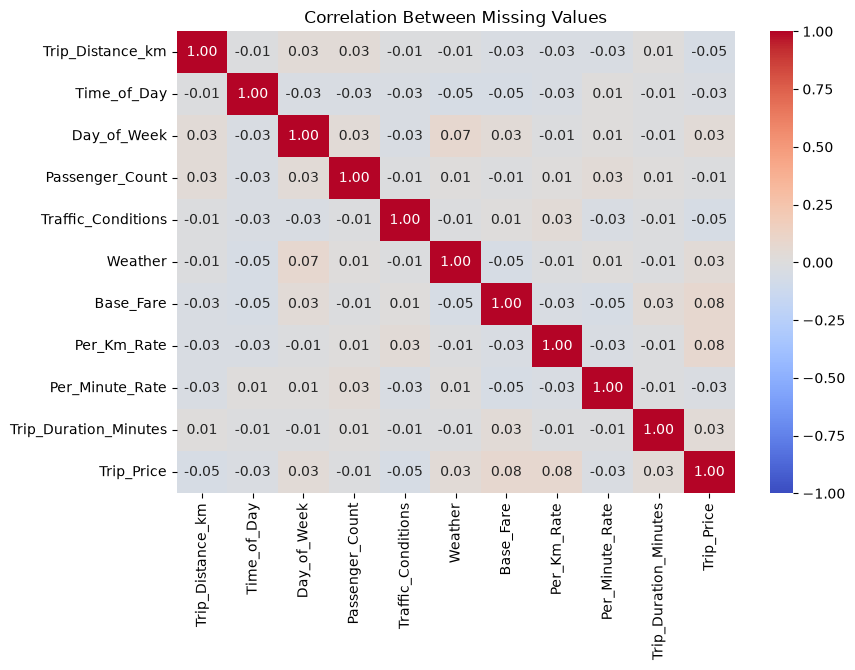

In [67]:
#missing value correlation
missing_correlation = df.isnull().corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    missing_correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Between Missing Values")
plt.show()

## Data cleaning

In [92]:
# Keep the original dataset unchanged
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", df_clean.shape)

# Remove observations with missing target variable
df_clean = df_clean.dropna(subset=["Trip_Price"]).copy()

print("Original observations:", len(df))
print("Remaining observations:", len(df_clean))
print("Removed observations:", len(df) - len(df_clean))


missing_after = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage (%)": df_clean.isnull().mean() * 100
})

display(missing_after.round(2))

Original shape: (1000, 11)
Working copy shape: (1000, 11)
Original observations: 1000
Remaining observations: 951
Removed observations: 49


,Missing Count,Missing Percentage (%)
Trip_Distance_km,50,5.26
Time_of_Day,49,5.15
Day_of_Week,46,4.84
Passenger_Count,48,5.05
Traffic_Conditions,50,5.26
Weather,46,4.84
Base_Fare,44,4.63
Per_Km_Rate,44,4.63
Per_Minute_Rate,49,5.15
Trip_Duration_Minutes,46,4.84


In [93]:
# Before deletion
before = df.describe(include="all").T
before["median"] = df.median(numeric_only=True)

# After deletion
after = df_clean.describe(include="all").T
after["median"] = df_clean.median(numeric_only=True)

display(before)
display(after)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,median
Trip_Distance_km,950.0,NaN,NaN,NaN,27.070547,19.9053,1.23,12.6325,25.83,38.405,146.067047,25.8300
Time_of_Day,950,4,Afternoon,371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,950,2,Weekday,655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger_Count,950.0,NaN,NaN,NaN,2.476842,1.102249,1.0,1.25,2.0,3.0,4.0,2.0000
Traffic_Conditions,950,3,Low,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,950,3,Clear,667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base_Fare,950.0,NaN,NaN,NaN,3.502989,0.870162,2.01,2.73,3.52,4.26,5.0,3.5200
Per_Km_Rate,950.0,NaN,NaN,NaN,1.233316,0.429816,0.5,0.86,1.22,1.61,2.0,1.2200
Per_Minute_Rate,950.0,NaN,NaN,NaN,0.292916,0.115592,0.1,0.19,0.29,0.39,0.5,0.2900
Trip_Duration_Minutes,950.0,NaN,NaN,NaN,62.118116,32.154406,5.01,35.8825,61.86,89.055,119.84,61.8600


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,median
Trip_Distance_km,901.0,NaN,NaN,NaN,27.190998,20.155134,1.23,12.63,25.87,38.68,146.067047,25.8700
Time_of_Day,902,4,Afternoon,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,905,2,Weekday,622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger_Count,903.0,NaN,NaN,NaN,2.479513,1.100983,1.0,2.0,2.0,3.0,4.0,2.0000
Traffic_Conditions,901,3,Low,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,905,3,Clear,634,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base_Fare,907.0,NaN,NaN,NaN,3.4971,0.866729,2.01,2.73,3.51,4.23,5.0,3.5100
Per_Km_Rate,907.0,NaN,NaN,NaN,1.229934,0.429958,0.5,0.85,1.22,1.61,2.0,1.2200
Per_Minute_Rate,902.0,NaN,NaN,NaN,0.293902,0.115404,0.1,0.19,0.29,0.39,0.5,0.2900
Trip_Duration_Minutes,905.0,NaN,NaN,NaN,62.044144,32.321578,5.01,35.59,61.57,89.21,119.84,61.5700


In [94]:
predictor_cols = [
    "Trip_Distance_km",
    "Time_of_Day",
    "Day_of_Week",
    "Passenger_Count",
    "Traffic_Conditions",
    "Weather",
    "Base_Fare",
    "Per_Km_Rate",
    "Per_Minute_Rate",
    "Trip_Duration_Minutes"
]

df_clean["Missing_Predictors"] = (
    df_clean[predictor_cols].isna().sum(axis=1)
)

#saving the numbers of observations after cleaning 
n_original = len(df)
n_missing_target = df["Trip_Price"].isna().sum()
n_before_multi_drop = len(df_clean)
n_multi_missing = (
    df_clean["Missing_Predictors"] >= 2
).sum()



In [95]:
# delete observations with multiple missing predictors
df_clean = df_clean[
    df_clean["Missing_Predictors"] < 2
].copy()

n_final_before_imputation = len(df_clean)

print("Original observations:", n_original)
print("Missing target removed:", n_missing_target)
print("Multiple-predictor-missing removed:", n_multi_missing)
print("Remaining observations:", n_final_before_imputation)

df_clean["Missing_Predictors"].value_counts().sort_index()

Original observations: 1000
Missing target removed: 49
Multiple-predictor-missing removed: 74
Remaining observations: 877


Missing_Predictors
0    562
1    315
Name: count, dtype: int64

In [ ]:
sample_summary = pd.DataFrame({
    "Processing Step": [
        "Original Dataset",
        "Remove Missing Target",
        "Remove ≥2 Missing Predictors",
        "Final Sample Before Imputation"
    ],
    "Removed": [
        0,
        n_missing_target,
        n_multi_missing,
        0
    ],
    "Remaining": [
        n_original,
        n_before_multi_drop,
        n_final_before_imputation,
        n_final_before_imputation
    ]
})

sample_summary["% of Original"] = (
    sample_summary["Remaining"] / n_original * 100
).round(1)

display(sample_summary)